### Necessary Imports

In [1]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [3]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0')
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### And divide them into their subpopulations

In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

### Now let's download the Leiner et al. (2022) SSG+RSCVn catalog

In [5]:
urlemilyleiner = "https://content.cld.iop.org/journals/0004-637X/927/2/222/revision1/apjac53b1t1_mrt.txt"
query_parameters = {"downloadformat": "txt"}
import requests
response = requests.get(urlemilyleiner, params=query_parameters)

with open("leiner.txt", mode="wb") as file:
    file.write(response.content)
subsubgiants = Table.read("leiner.txt", format="ascii.cds").to_pandas().rename(columns={'ID':'edr3_source_id'})


In [6]:
merged = pd.merge(subgiants, subsubgiants, on='edr3_source_id', how='inner')
#merged #575 matched in full, 574 in sg grouping out opf 46727 total

### Now let's plot

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_42947/1844719290.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


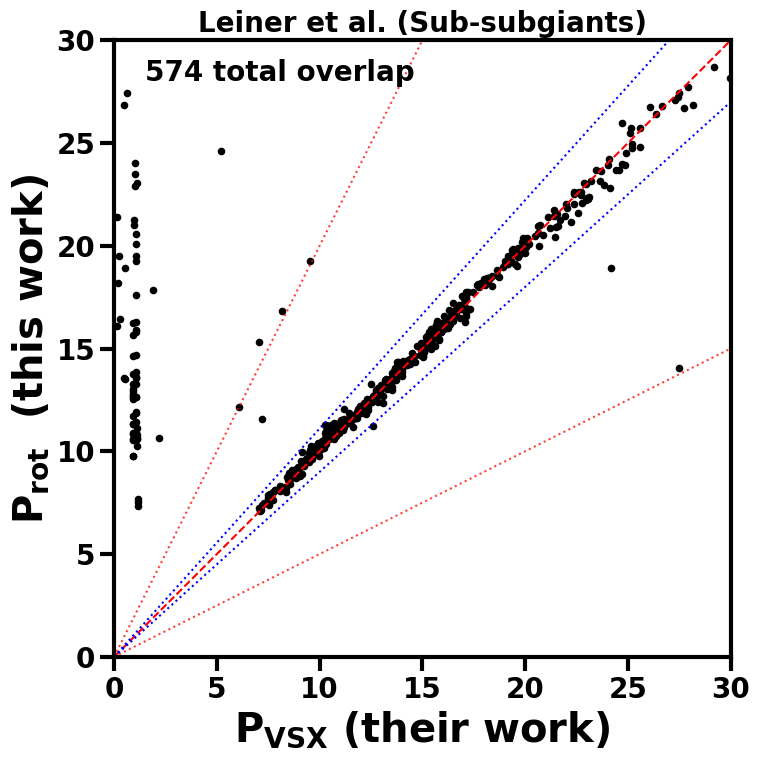

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8), layout='constrained')

axs.plot([0, 30], [0, 30], "r--", label="1:1", rasterized=True)
axs.plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
axs.plot([0, 30], [0, 30*0.9], "b:", rasterized=True)
axs.plot([0, 30], [0, 30*2], "r:",  label="2:1 and 1:2 aliases", alpha=0.75, rasterized=True)
axs.plot([0, 30], [0, 30*0.5], "r:", alpha=0.75, rasterized=True)

axs.set_xlim(0, 30)
axs.set_ylim(0, 30)
axs.set_xlabel('P$\\bf _{VSX}$ (their work)')
axs.set_ylabel('P$\\bf _{rot}$  (this work)')
axs.text(1.5, 28, f"{len(merged)} total overlap",  rasterized=True)
axs.scatter('PVSX', 'period' , data=merged, c='k', s=20, rasterized=True)
axs.set_title('Leiner et al. (Sub-subgiants)', fontweight='bold', fontsize=20, rasterized=True)
plt.tight_layout()
plt.show()